# Мультимодальная нейросеть для предсказания калорийности блюд

**Задача:** создать и обучить нейросеть, которая будет предсказывать калорийность блюд. Полученную модель можно интегрировать во многие fitness и health-приложения, она будет полезна тем, кто следит за своим здоровьем.

**Целевая метрика:** модель будет считаться готовой к интеграции в продукт при точности оценки MAE < 50 (MAE — Mean Absolute Error) на тестовой выборке.

**Датасет**:
- фотографии блюд
- таблицы с описанием блюд (ингредиенты, масса, калорийность)

**План работы**
- Проведение EDA и подготовка датасета к обучению модели.
- Создание и дообучение мультимодельной модели (Transfer Learning), состоящей из модели распознавания изображений (*tf_efficientnet_b0*) и модели для работы с текстом (*bert-base-uncased*).
- Исследование качества модели. Модель будет считаться готовой к интеграции в продукт при точности оценки MAE < 50. Выводы и рекомендации.

In [1]:
from collections import Counter
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import timm
import torch
from transformers import AutoTokenizer

from scripts.utils import Config
from scripts.dataset import create_dataloader
from scripts.model import train, evaluate

/home/ubuntu/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = Config()

1. Исследовательский анализ данных (EDA)

1.1. Загрузка данных

Загрузим данные об ингредиентах из **таблицы ingredients**:

In [3]:
try:
    ingredients_df = pd.read_csv(f'{cfg.DATA_DIR}/ingredients.csv')
except Exception as e:
    print(f'Не удалось загрузить файл: {e}')
    ingredients_df = None

if ingredients_df is not None:
    display(ingredients_df.shape)
    display(ingredients_df.head())

(555, 2)

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


Данные содержат записи о 555 ингредиентах с указанем их названия:
- **id** - ID ингредиента
- **ingr** - название ингредиента

Загрузим данные о блюдах из **таблицы dish**:

In [4]:
try:
    dish_df = pd.read_csv(f'{cfg.DATA_DIR}/dish.csv')
except Exception as e:
    print(f'Не удалось загрузить файл: {e}')
    dish_df = None

if dish_df is not None:
    display(dish_df.shape)
    display(dish_df.head())

(3262, 5)

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


Данные содержат записи о 3262 блюдах в разрезе следующих параметров:
- **dish_id** - ID блюда. Соответствует названию папки с фотографией этошо блюда в директории images
- **total_calories** - общее число калорий. Это **целевая переменная**
- **total_mass** - масса блюда
- **ingredients** - спискок всех ID ингредиентов в формате ingr_0000000122;ingr_0000000026;..где ненулевая часть соответствует ID ингредиента из таблицы data/ingredients.csv
- **split** - метка, указывающая, куда отнести блюдо: train/test

1.2. Общий обзор и проверка данных

1.2.1. Ингредиенты (ingredients)

В таблице 555 записей, очевидных пропущенных значений нет, типы данных верны:

In [5]:
display(ingredients_df.info())
display(ingredients_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


None

id      0
ingr    0
dtype: int64

Явных дубликатов в данных нет, однако есть 3 записи-дубликата, если рассматривать данные без учета id:

In [6]:
display(ingredients_df.duplicated().sum())
display(ingredients_df['ingr'].duplicated().sum())

np.int64(0)

np.int64(3)

По сути данные ингредиенты являются пропущенными значениями - данные устарели и были удалены.

In [7]:
ingredients_df[ingredients_df.duplicated(subset=['ingr'], keep=False)]

,id,ingr
230,231,deprecated
452,453,deprecated
457,458,deprecated
469,470,deprecated


Проверим, используются ли эти ингредиенты в таблице с блюдами и также посмотрим на фотографиях, что это за ингредиенты:

In [8]:
deprecated_ids = ingredients_df.loc[ingredients_df['ingr'] == 'deprecated', 'id']
deprecated_ids_str = {f'ingr_{i:010d}' for i in deprecated_ids.tolist()}
deprecated_ids_str

{'ingr_0000000231', 'ingr_0000000453', 'ingr_0000000458', 'ingr_0000000470'}

В таблице dish есть 31 запись с ингредиентами из списка устаревших (по которым нет корректного названия ингредиента):

In [9]:
def get_deprecated_info(ingredients_str):
    ingrs = ingredients_str.split(';')
    deprecated = [i for i in ingrs if i in deprecated_ids_str]
    return pd.Series([len(deprecated) > 0, deprecated])

dish_df[['has_deprecated', 'deprecated_ingrs']] = (
    dish_df['ingredients'].apply(get_deprecated_info)
)

display(dish_df['has_deprecated'].sum())
display(dish_df.loc[dish_df['has_deprecated']])

np.int64(31)

,dish_id,total_calories,total_mass,ingredients,split,has_deprecated,deprecated_ingrs
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train,True,[ingr_0000000453]
55,dish_1558114086,74.360001,143.0,ingr_0000000453,test,True,[ingr_0000000453]
123,dish_1558027001,20.400002,68.0,ingr_0000000458,train,True,[ingr_0000000458]
334,dish_1558373159,1013.337036,334.0,ingr_0000000039;ingr_0000000453;ingr_0000000077,test,True,[ingr_0000000453]
594,dish_1558115364,485.260010,313.0,ingr_0000000005;ingr_0000000453;ingr_000000007...,train,True,[ingr_0000000453]
701,dish_1558114875,74.360001,143.0,ingr_0000000453,train,True,[ingr_0000000453]
749,dish_1558375506,73.839996,142.0,ingr_0000000453,train,True,[ingr_0000000453]
908,dish_1558028142,21.900002,73.0,ingr_0000000458,train,True,[ingr_0000000458]
1025,dish_1558031019,206.442001,197.0,ingr_0000000192;ingr_0000000004;ingr_000000045...,train,True,[ingr_0000000458]
1068,dish_1558030724,18.300001,61.0,ingr_0000000458,train,True,[ingr_0000000458]


Можно заметить, что из 4 неизвестных ингредиентов лишь 2 встречаются в блюдах:

In [10]:

dish_deprecated_ingrs = dish_df.loc[dish_df['has_deprecated'] == True, 'deprecated_ingrs'].tolist()
set([ingr for ingrs in dish_deprecated_ingrs for ingr in ingrs])

{'ingr_0000000453', 'ingr_0000000458'}

Попробуем определить по фотографиям блюд, что это за ингредиенты.\
2 неизвестных и не участвующих в блюдах продукта проигнорируем (также можно удалить, но так как данная таблица скорее носит справочно-вспомогательный характер, это не принципиально).

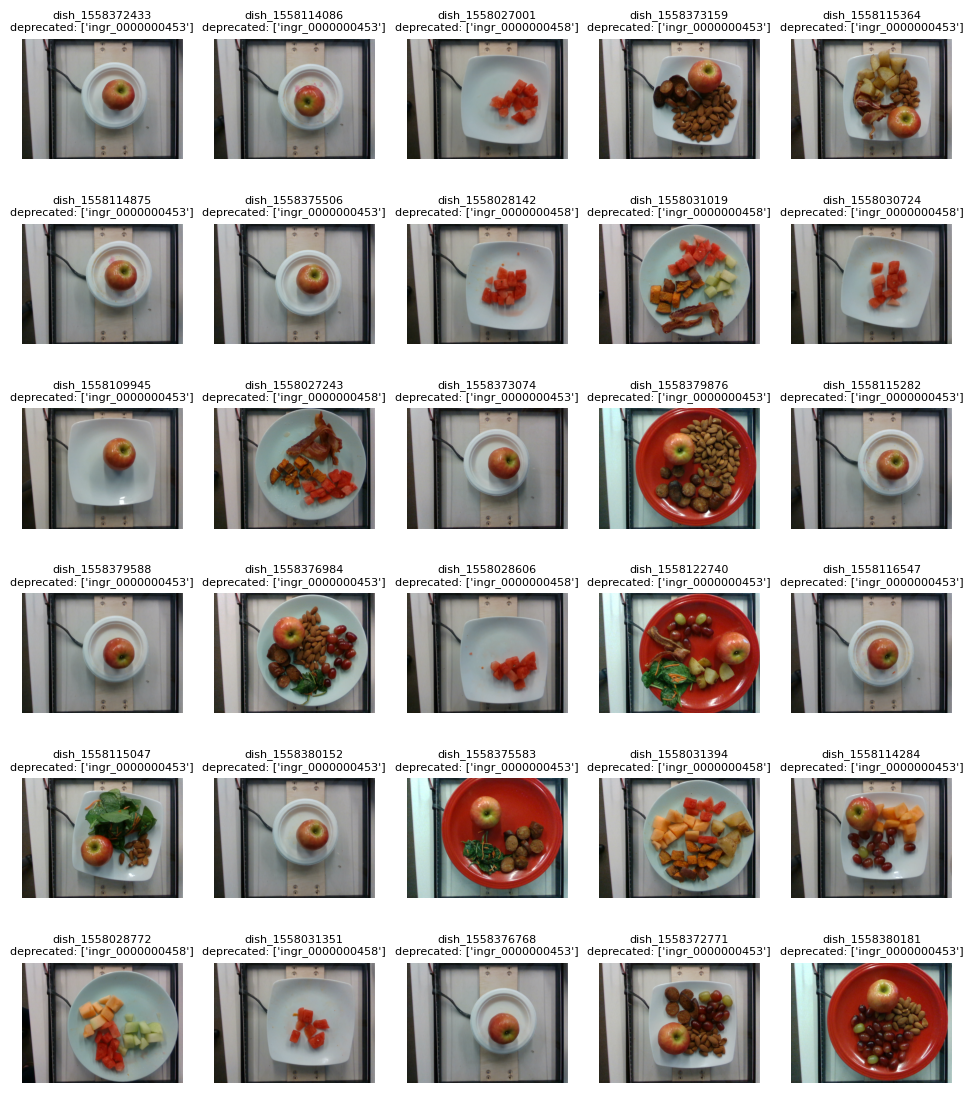

In [11]:
has_deprecated = dish_df[dish_df['deprecated_ingrs'].str.len() > 0].reset_index(drop=True)

fig = plt.figure(figsize=(12, 14))
for i in range(30):
    image_path = f'{cfg.IMAGE_DIR}/{has_deprecated.loc[i, "dish_id"]}/rgb.png'
    label = f'{has_deprecated.loc[i, "dish_id"]}\ndeprecated: {has_deprecated.loc[i, "deprecated_ingrs"]}'
    plt.subplot(6, 5, i+1)
    plt.imshow(Image.open(image_path))
    plt.title(label, fontsize=8)
    plt.axis('off')

По фотографиям легко установить названия пропущенных ингредиентов:
- 453 - яблоко (apple)
- 458 - арбуз (watermelon)

При этом данные ингредиенты содержатся в таблице под другими индексами:

In [12]:
ingredients_df[ingredients_df['ingr'].isin(['apple', 'watermelon'])]

,id,ingr
53,54,apple
120,121,watermelon


В таблице dish заменим deprecated ингредиенты 453 и 458 на актуальные:

In [13]:
old_new_ids_map = {'ingr_0000000453': 'ingr_0000000054', 'ingr_0000000458': 'ingr_0000000121'}

def replace_ingredients(ingredients_str):
    ingrs = ingredients_str.split(';')
    new_ingrs = []
    for ingr in ingrs:
        if ingr in old_new_ids_map:
            new_ingrs.append(old_new_ids_map[ingr])
        else:
            new_ingrs.append(ingr)
    return ';'.join(new_ingrs)

dish_df['ingredients'] = dish_df['ingredients'].apply(replace_ingredients)

Удалим вспомогательные столбцы, которые создавали при работе с ингредиентами:

In [14]:
dish_df = dish_df.drop(['has_deprecated', 'deprecated_ingrs'], axis=1)

1.2.2. Блюда (dish)

В таблице 3262 записи, очевидных пропущенных значений нет, типы данных верны:

In [15]:
display(dish_df.info())
display(dish_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


None

dish_id           0
total_calories    0
total_mass        0
ingredients       0
split             0
dtype: int64

Проверим данные на наличие дубликатов.

In [16]:
dish_df.duplicated().sum()

np.int64(0)

Явных дубликатов в таблице нет, однако стоит провести более детальную проверку: 
- не учитывать столбец с id блюда, т.к. разные id могут относиться к одинаковым блюдам
- нормализовать список ингредиентов, упорядочив его по алфавиту - у дубликатов может быть одинаковый состав, но разный порядок ингредиентов.

Упорядочим список ингредиентов в алфавитном порядке:

In [17]:
dish_df['ingredients_norm'] = dish_df['ingredients'].apply(lambda x: ';'.join(sorted([i.strip() for i in x.split(';')])))
dish_df.head()

,dish_id,total_calories,total_mass,ingredients,split,ingredients_norm
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test,ingr_0000000023;ingr_0000000026;ingr_000000002...
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train,ingr_0000000026;ingr_0000000029;ingr_000000004...
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test,ingr_0000000006;ingr_0000000045;ingr_000000011...
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train,ingr_0000000031;ingr_0000000347;ingr_0000000471
4,dish_1558372433,74.360001,143.0,ingr_0000000054,train,ingr_0000000054


Без учета id блюда/его изображения данные содержат 176 дубликатов:

In [18]:
cols = [c for c in dish_df.columns if c not in ['dish_id', 'ingredients']]
dish_df.duplicated(subset=cols).sum()

np.int64(176)

In [19]:
duplicates = dish_df[dish_df.duplicated(subset=cols, keep=False)].sort_values(by=cols).reset_index(drop=True)
duplicates.head(10)

,dish_id,total_calories,total_mass,ingredients,split,ingredients_norm
0,dish_1558546434,2.530000,11.0,ingr_0000000036,test,ingr_0000000036
1,dish_1559157777,2.530000,11.0,ingr_0000000036,test,ingr_0000000036
2,dish_1558462036,2.990000,13.0,ingr_0000000036,train,ingr_0000000036
3,dish_1559158425,2.990000,13.0,ingr_0000000036,train,ingr_0000000036
4,dish_1558639907,10.440001,58.0,ingr_0000000471,train,ingr_0000000471
5,dish_1558722842,10.440001,58.0,ingr_0000000471,train,ingr_0000000471
6,dish_1558721484,11.160001,62.0,ingr_0000000471,train,ingr_0000000471
7,dish_1558721959,11.160001,62.0,ingr_0000000471,train,ingr_0000000471
8,dish_1561492628,13.640000,31.0,ingr_0000000006,train,ingr_0000000006
9,dish_1557861795,13.640000,31.0,ingr_0000000006,train,ingr_0000000006


Визуализировав дубликаты, можно заметить, что хоть состав блюд действительно одинаковый, блюда сфотографированы в разных ракурсах и/или на тарелках разной формы, что не является дубликатами и наоборот полезно для обучения модели. Также можно отметить, что в датасете есть близкие данные, где блюдо одно и то же, но немного отличается масса и, соответственно, количество калорий.

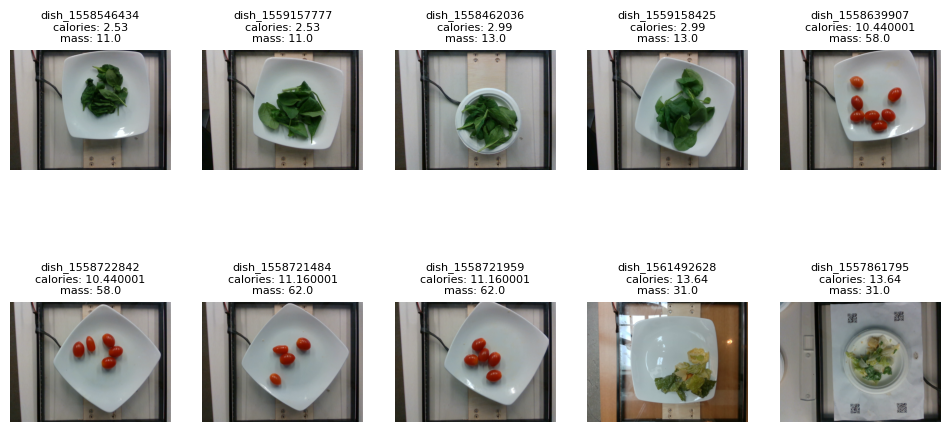

In [20]:
fig = plt.figure(figsize=(12, 6))
for i in range(10):
    image_path = f'{cfg.IMAGE_DIR}/{duplicates.loc[i, "dish_id"]}/rgb.png'
    label = f'{duplicates.loc[i, "dish_id"]}\ncalories: {duplicates.loc[i, "total_calories"]}\nmass: {duplicates.loc[i, "total_mass"]}'
    plt.subplot(2, 5, i+1)
    plt.imshow(Image.open(image_path))
    plt.title(label, fontsize=8)
    plt.axis('off')

Убедимся, что для каждой записи из таблицы dish есть соответствующее изображение.

In [21]:
img_path = Path(cfg.IMAGE_DIR)
folders = [p for p in img_path.iterdir() if p.is_dir()]
print(f'Всего папок с изображениями: {len(folders)}')
print(f'Всего блюд: {dish_df.shape[0]}')

Всего папок с изображениями: 3490
Всего блюд: 3262


Получается, что папок с изображениями блюд больше, чем самих блюд в таблице dish. Это не критично - в данном случае часть фотографий не будет использоваться при обучении модели.

В каждой из папок хранится по 1 фотографии:

In [22]:
counts = []

for folder in folders:
    n_files = len([f for f in folder.iterdir() if f.is_file()])
    counts.append(n_files)

Counter(counts)

Counter({1: 3490})

Убедимся, что для каждого блюда из таблицы dish есть соответствующее изображение:

In [23]:
dish_ids = set(dish_df['dish_id'])
folder_names = set(p.name for p in folders)

missing_folders = dish_ids - folder_names
print(f'Нет папок для {len(missing_folders)} dish_id')


Нет папок для 0 dish_id


Проверка показала, что каждому блюду из таблицы dish соответствует 1 фотография.

In [24]:
dish_df.describe()

,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


В данных представлено 2 записи, калорийность блюд в которых равна 0. Посмотрим фотографии этих блюд.

In [25]:
dish_df.query('total_calories == 0')

,dish_id,total_calories,total_mass,ingredients,split,ingredients_norm
263,dish_1557861216,0.0,1.0,ingr_0000000423,test,ingr_0000000423
2652,dish_1556575700,0.0,86.0,ingr_0000000423,train,ingr_0000000423


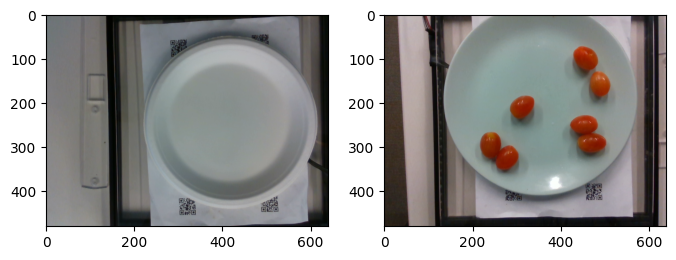

In [26]:
fig = plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(Image.open(f'{cfg.IMAGE_DIR}/dish_1557861216/rgb.png'))

plt.subplot(1, 2, 2)
plt.imshow(Image.open(f'{cfg.IMAGE_DIR}/dish_1556575700/rgb.png'))

Первая запись корректна - ингредиент 423 соответствует пустой тарелке, что мы видим и на фото. Калорийность, равная 0, также объяснима.
Что касается второй записи, то она неверна - как с точки зрения ингредиентов (указана только тарелка), так и с точки зрения калорийности. Удалим эту запись.

In [27]:
dish_df = dish_df.query('dish_id != "dish_1556575700"')
dish_df.shape

(3261, 6)

1.3 Анализ данных

Подготовим функцию для удобства визуализации данных.

In [28]:
def display_histogram_and_boxplot(df, column, title, label_hist, label_box, bins_hist=10):
    """Строит для указанного признака гистограмму и диаграмму размаха, расположенные рядом."""
    
    data = df[column]
    
    plt.figure(figsize=(15,6))
    plt.suptitle(title)
    
    plt.subplot(1, 2, 1)
    bins = plt.hist(data, bins=bins_hist)
    plt.vlines(x=data.mean(), colors='red', ymin=0, ymax=bins[0].max(), label='Среднее')
    plt.vlines(x=data.median(), colors='red', ymin=0, ymax=bins[0].max(), linestyles='--', label='Медиана')
    plt.legend()
    plt.xlabel(label_hist[0])
    plt.ylabel(label_hist[1])      
        
    plt.subplot(1, 2, 2)
    plt.boxplot(df[column])
    plt.ylabel(label_box)
    plt.xticks([])

    plt.show()

1.3.1. Тип выборки

В таблице dish предусмотрено разбиение данных на обучающую и тестовую выборки. Посмотрим их объемы:

In [29]:
dish_df['split'].value_counts()

split
train    2754
test      507
Name: count, dtype: int64

Тестовая выборка составляет около 15% данных, обучающая - 85%

1.3.2. Калорийность блюд

Посмотрим на распределение данных по **калорийности блюд**:

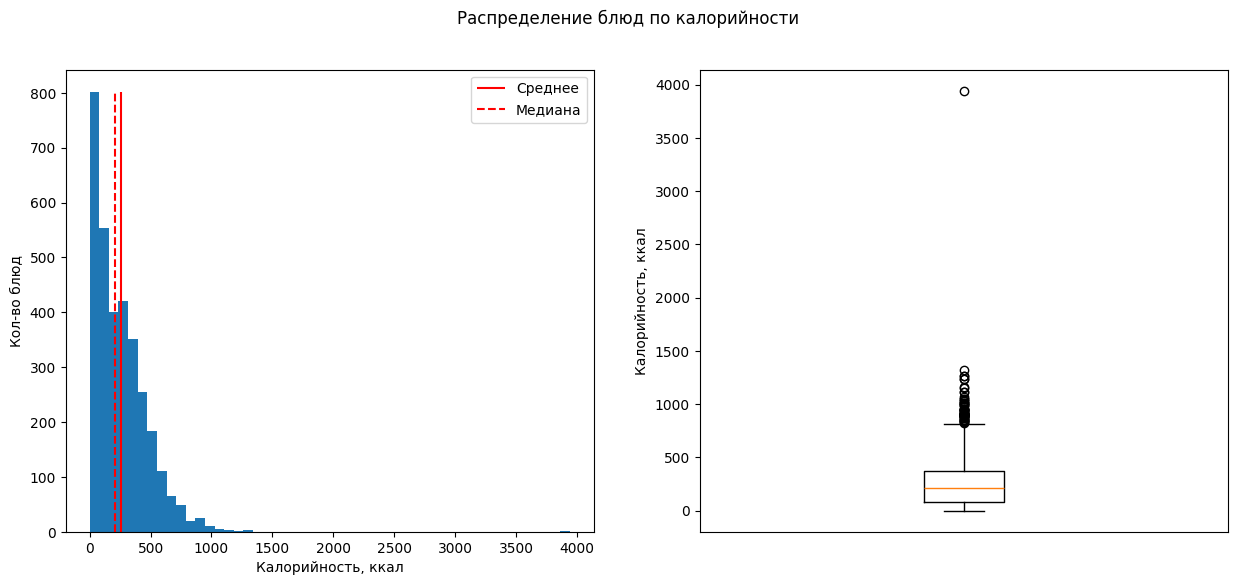

In [30]:
display_histogram_and_boxplot(
    df=dish_df,
    column='total_calories',
    title='Распределение блюд по калорийности',
    label_hist=('Калорийность, ккал', 'Кол-во блюд'),
    label_box='Калорийность, ккал',
    bins_hist=50)

Одно блюдо значительно отличается по своей калорийности. Это может быть верной информацией с учетом большого веса, однако с учетом всего 1 записи подобного формата она не поможет в обучении. Удалим этот выброс

In [31]:
dish_df.query('total_calories > 3000')

,dish_id,total_calories,total_mass,ingredients,split,ingredients_norm
1518,dish_1560974769,3943.325195,3051.0,ingr_0000000036;ingr_0000000251;ingr_000000004...,train,ingr_0000000026;ingr_0000000032;ingr_000000003...


In [32]:
dish_df = dish_df.query('total_calories < 3000')
dish_df.shape

(3260, 6)

Обновим гистограмму:

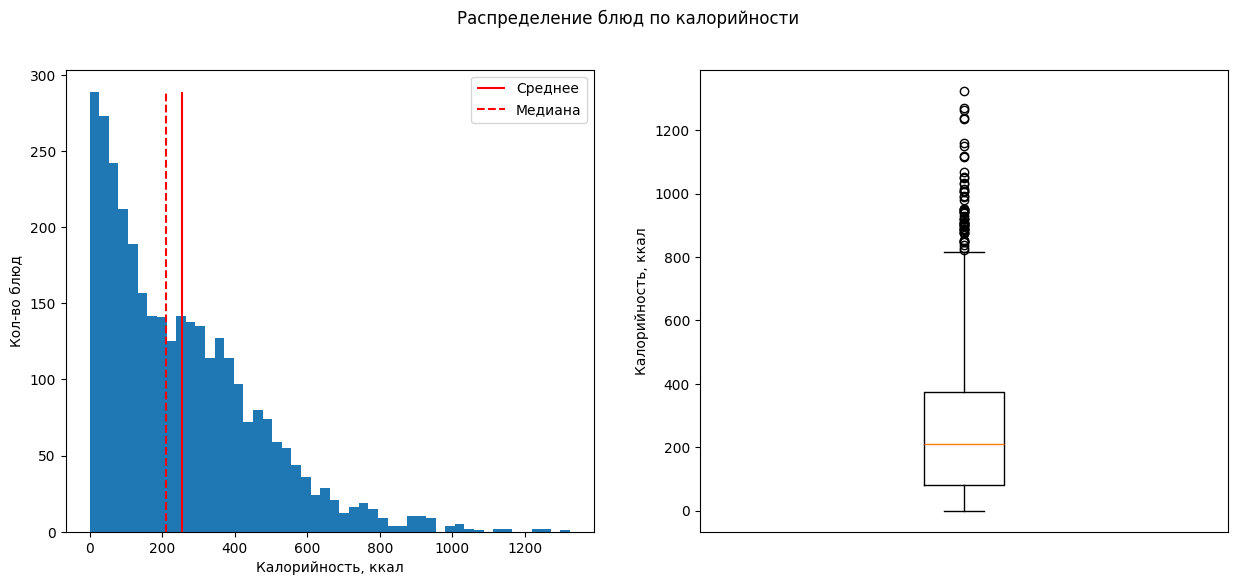

In [33]:
display_histogram_and_boxplot(
    df=dish_df,
    column='total_calories',
    title='Распределение блюд по калорийности',
    label_hist=('Калорийность, ккал', 'Кол-во блюд'),
    label_box='Калорийность, ккал',
    bins_hist=50)

In [34]:
dish_df['total_calories'].describe()

count    3260.000000
mean      253.959579
std       209.940525
min         0.000000
25%        80.184999
50%       209.110062
75%       375.114311
max      1324.084961
Name: total_calories, dtype: float64

Калорийность 75% блюд в датасете не превышает 375 ккал, среднее значение - 256 ккал, медианное 209.
Распределение смещено в левую сторону и имеет хвост - блюда с калорийностью > 800 ккал присутствуют в выборке, однако их не так много, что может привести к бОльшим ошибкам по блюдам с высокой калорийностью.

1.3.3. Вес блюд

Построим распределение блюд **по весу**:

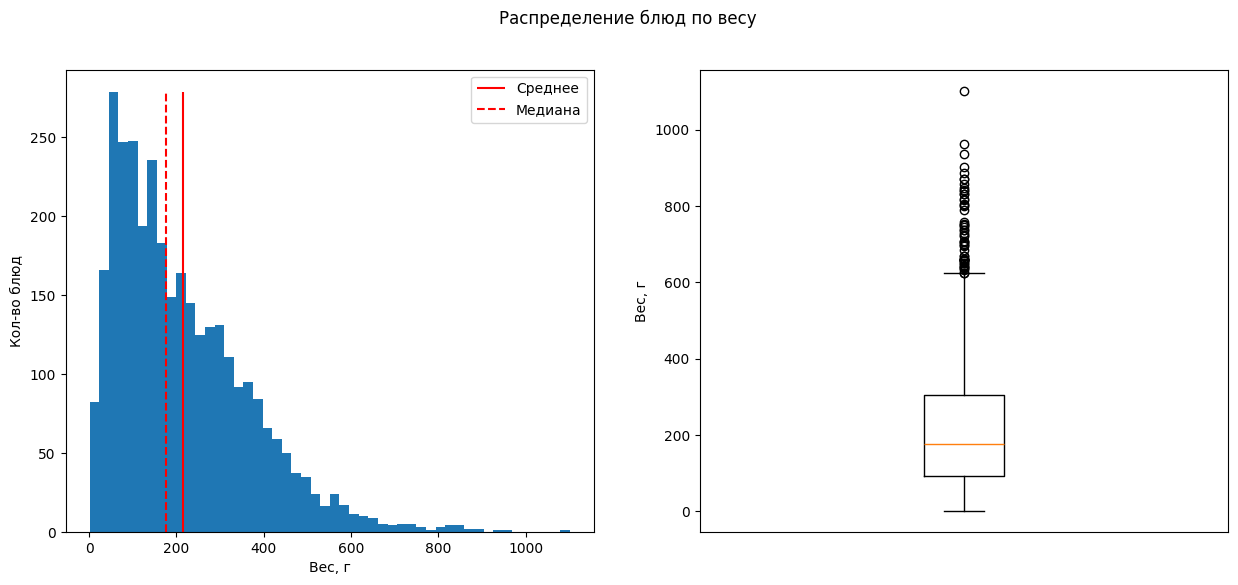

In [35]:
display_histogram_and_boxplot(
    df=dish_df,
    column='total_mass',
    title='Распределение блюд по весу',
    label_hist=('Вес, г', 'Кол-во блюд'),
    label_box='Вес, г',
    bins_hist=50)

In [36]:
dish_df['total_mass'].describe()

count    3260.000000
mean      214.149693
std       153.700009
min         1.000000
25%        92.000000
50%       177.000000
75%       305.000000
max      1102.000000
Name: total_mass, dtype: float64

Средний вес блюд в датасете - 214 грамм, медиана - 177 г.
Вес 75% блюд в датасете не превышает 305 г, при этом есть некое количество блюд с весом более 600 грамм, однако их не так много, что может привести к бОльшим ошибкам по блюдам с высоким весом. 

В целом можно предположить, что для того, чтобы модель хорошо обучилась отмечать закономерности между объемом порции и калорийностью одного и того же блюда, было бы хорошо, если бы датасет содержал бы данные, которые могли бы помочь обучить модель этой закономерностью.

Исследуем **взаимозависимость калорийности и веса блюда**:

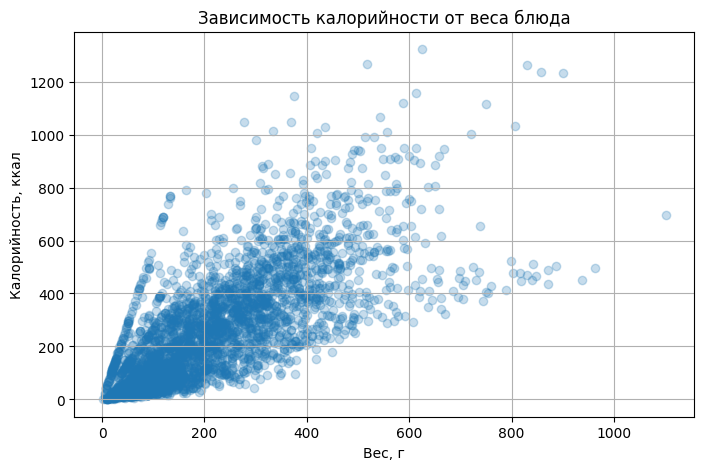

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(dish_df['total_mass'], dish_df['total_calories'], alpha=0.25)
plt.title('Зависимость калорийности от веса блюда')
plt.xlabel('Вес, г')
plt.ylabel('Калорийность, ккал')
plt.grid(True)
plt.show()

Видно, что с увеличением массы калорийность увеличивается, однако распределение достаточно широкое, что говорит о том, что есть и другие факторы, влияющие на рост калорийности (ингредиенты).

1.3.3. Количество ингредиентов

Исследуем данные на **количество ингредиентов в блюдах**:

In [38]:
dish_df['n_ingredients'] = dish_df['ingredients'].str.split(';').str.len()
dish_df.head()

,dish_id,total_calories,total_mass,ingredients,split,ingredients_norm,n_ingredients
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test,ingr_0000000023;ingr_0000000026;ingr_000000002...,17
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train,ingr_0000000026;ingr_0000000029;ingr_000000004...,17
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test,ingr_0000000006;ingr_0000000045;ingr_000000011...,13
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train,ingr_0000000031;ingr_0000000347;ingr_0000000471,3
4,dish_1558372433,74.360001,143.0,ingr_0000000054,train,ingr_0000000054,1


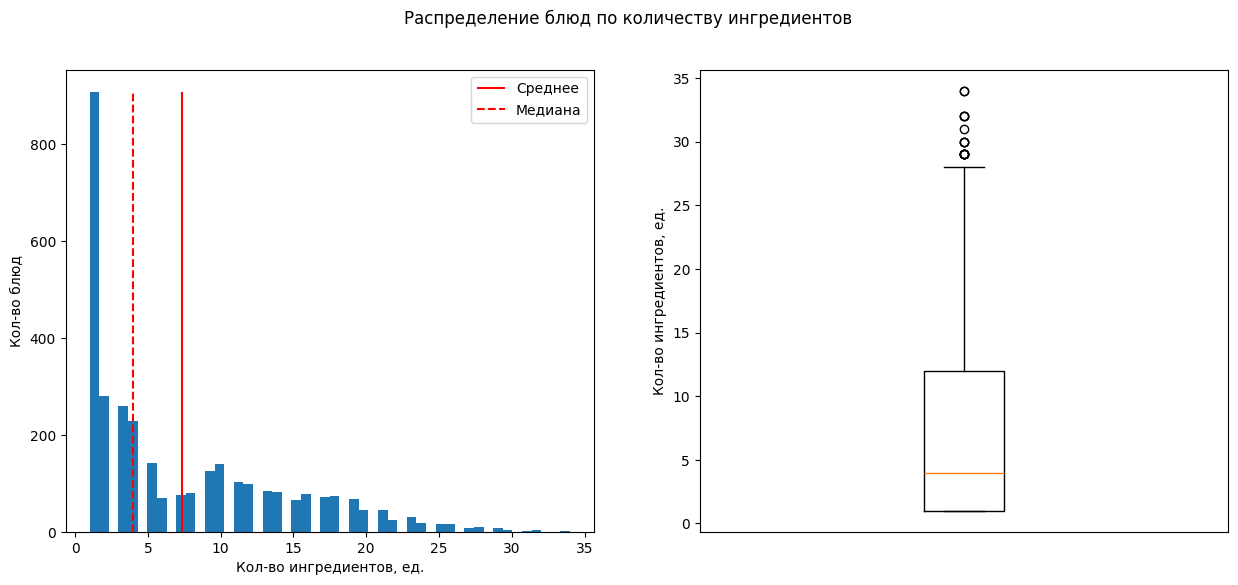

In [39]:
display_histogram_and_boxplot(
    df=dish_df,
    column='n_ingredients',
    title='Распределение блюд по количеству ингредиентов',
    label_hist=('Кол-во ингредиентов, ед.', 'Кол-во блюд'),
    label_box='Кол-во ингредиентов, ед.',
    bins_hist=50)

In [40]:
dish_df['n_ingredients'].describe()

count    3260.000000
mean        7.313190
std         6.943538
min         1.000000
25%         1.000000
50%         4.000000
75%        12.000000
max        34.000000
Name: n_ingredients, dtype: float64

Датасет содержит существенное количество (более четверти) записей, где блюдо состоит из всего 1 ингредиента.\
Максимальное количество ингредиентов - 34.\
Основная часть данных приходится на блюда, включающие до 20 ингредиентов

In [41]:
dish_df.head()

,dish_id,total_calories,total_mass,ingredients,split,ingredients_norm,n_ingredients
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test,ingr_0000000023;ingr_0000000026;ingr_000000002...,17
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train,ingr_0000000026;ingr_0000000029;ingr_000000004...,17
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test,ingr_0000000006;ingr_0000000045;ingr_000000011...,13
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train,ingr_0000000031;ingr_0000000347;ingr_0000000471,3
4,dish_1558372433,74.360001,143.0,ingr_0000000054,train,ingr_0000000054,1


Удалим вспомогательные столбцы:

In [42]:
dish_df = dish_df.drop(['ingredients_norm'], axis=1)

Сохраним очищенный датасет:

In [43]:
dish_df.to_csv('data/dish_cleaned.csv')

**Выводы:**
- Датасет в целом обладает высоким качеством: пропуски отсутствуют, критичных ошибок не выявлено
- Было обнаружено несколько неизвестных ингредиентов, названия которых были восстановлены по фотографиям
- Обнаруженные а данных дубликаты являются допустимыми, так как связаны с фотографиями, представляющими одно и то же блюдо в разных визуальных вариациях.
- Распределение калорийности и веса смещено в сторону меньших значений, при этом наблюдаются редкие экстремальные значения, что может ухудшать качество модели на калорийных и/или «тяжёлых» блюдах.
- Между весом блюда и калорийностью прослеживается положительная зависимость, однако разброс значений указывает на значимое влияние состава ингредиентов.
- Датасет содержит как простые блюда (с одним ингредиентом), так и более сложные, что повышает его разнообразие.

В целом данные подходят для обучения мультимодальной модели, но для повышения качества желательно увеличить представленность блюд с высокой калорийностью и массой.

2. Обучение модели

2.1. Подготовка данных

Разделим данные на обучающую, валидационную и тестовую выборки и создадим загрузчики данных.

In [44]:
train_val_df = dish_df.query('split == "train"').reset_index(drop=True)
test_df = dish_df.query('split == "test"').reset_index(drop=True)
train_df, val_df = train_test_split(
    train_val_df, test_size=cfg.VAL_SIZE, random_state=cfg.RANDOM_SEED
)

print(f'Обучающая выборка: {train_df.shape[0]} записей')
print(f'Валидационная выборка: {val_df.shape[0]} записей')
print(f'Тестовая выборка: {test_df.shape[0]} записей')

Обучающая выборка: 2340 записей
Валидационная выборка: 413 записей
Тестовая выборка: 507 записей


In [45]:
tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)
image_model_cfg = timm.get_pretrained_cfg(cfg.IMAGE_MODEL_NAME)

In [46]:
train_dataloader = create_dataloader(train_df, ingredients_df, tokenizer, image_model_cfg, cfg, mode='train')
val_dataloader = create_dataloader(val_df, ingredients_df, tokenizer, image_model_cfg, cfg, mode='val')

/home/ubuntu/Sprint_4_project/scripts/dataset.py:91: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),


2.2. Обучение модели

Создадим мультимодальную модель на основе:
- **bert-base-uncased** для текстовых данных
- **tf_efficientnet_b0** для изображений
и дообучим их, разморозив веса нескольких последних слоев.

В качестве ключевой метрики при валидации будем ориентироваться на MAE.

Обучение модели запущено на cuda.

Эпоха 1


val: 100%|██████████| 26/26 [00:07<00:00,  3.58it/s]


Epoch 1/30 | train Loss: 222.5935 | val MAE: 176.1872
Модель эпохи 1 c MAE 176.1872 сохранена.

Эпоха 2


val: 100%|██████████| 26/26 [00:07<00:00,  3.34it/s]


Epoch 2/30 | train Loss: 130.0855 | val MAE: 84.9040
Модель эпохи 2 c MAE 84.9040 сохранена.

Эпоха 3


...

Epoch 28/30 | train Loss: 40.8490 | val MAE: 38.8552

Эпоха 29


val: 100%|██████████| 26/26 [00:07<00:00,  3.58it/s]


Epoch 29/30 | train Loss: 41.5282 | val MAE: 44.5670

Эпоха 30


val: 100%|██████████| 26/26 [00:07<00:00,  3.58it/s]

Epoch 30/30 | train Loss: 39.7803 | val MAE: 40.1990


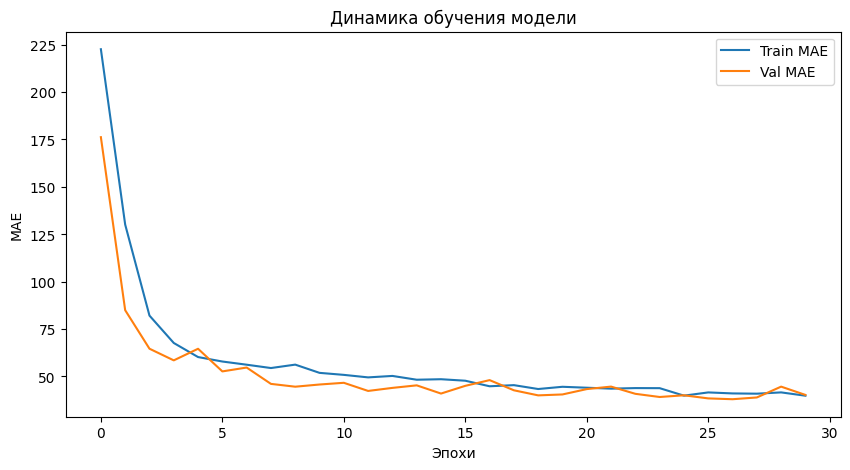

In [47]:
model = train(train_dataloader, val_dataloader, cfg)

В ходе обучения на 30 эпохах лучший результат модель показала на 27 эпохе - её мы будем использовать далее для тестирования.

3. Тестирование модели

Подготовим загрузчик данных для тестирования модели:

In [48]:
test_dataloader = create_dataloader(test_df, ingredients_df, tokenizer, image_model_cfg, cfg, mode='test')

Загрузим веса сохраненной лучшей версии модели:

In [49]:
model.load_state_dict(torch.load(os.path.join(cfg.SAVE_MODEL_DIR, cfg.SAVE_MODEL_NAME)))

<All keys matched successfully>

In [50]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
mae, preds, targets, errors = evaluate(model, test_dataloader, device, return_details=True)
print(f'MAE на тестовой выборке: {mae:.4f}')

test: 100%|██████████| 32/32 [00:18<00:00,  1.74it/s]

MAE на тестовой выборке: 46.4762


MAE на тестовой выборке составляет 46,4762 ккал, что соответствует требованиям технического задания (MAE <= 50)

Визуализируем 5 объектов с наибольшей ошибкой в предсказании:

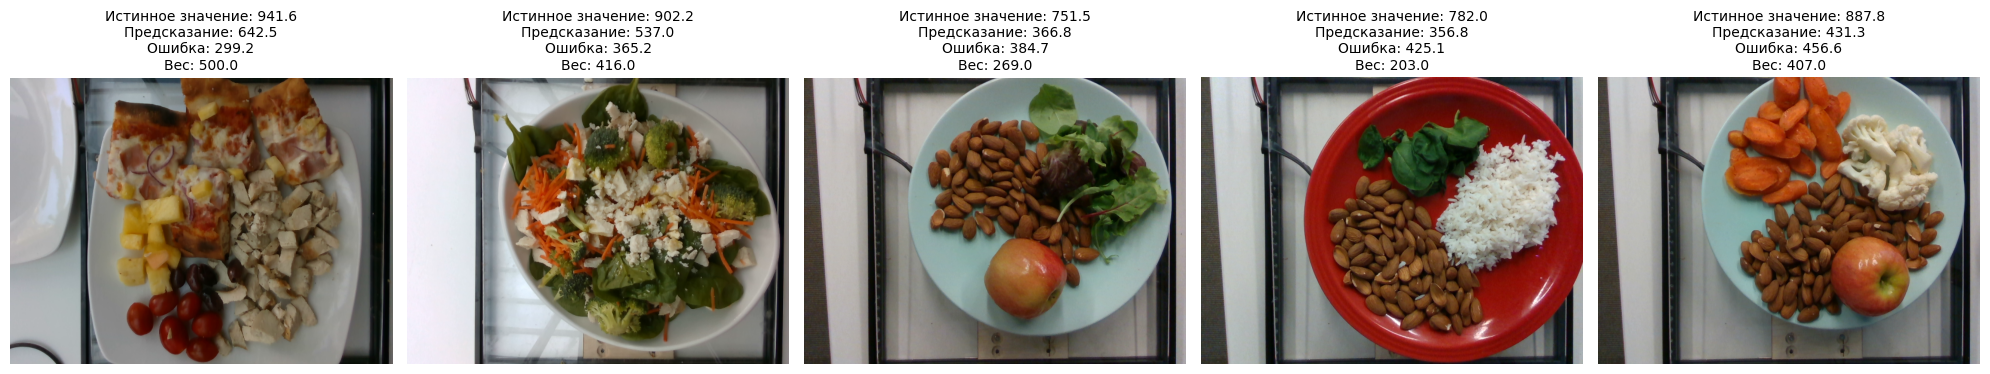

In [55]:
top5_idx = np.argsort(errors)[-5:]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # 1 ряд, 5 колонок

for i, idx in enumerate(top5_idx):
    row = test_df.iloc[idx]
    dish_id = row['dish_id']
    
    img = Image.open(f'{cfg.IMAGE_DIR}/{dish_id}/rgb.png')
    
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f'Истинное значение: {targets[idx]:.1f}\nПредсказание: {preds[idx]:.1f}\nОшибка: {errors[idx]:.1f}\nВес: {row["total_mass"]}',
        fontsize=10
    )

plt.tight_layout()
plt.show()

Вероятные причины высоких ошибок на указанных выше блюдах могут быть следующими:
- недостаток в датасете примеров с высокой калорийностью и/ или высоким весом - высокая ошибка возникает именно на таких блюдах
- сложность определения состава на некоторых блюдах (например, салат со смешенными ингредиентами или пицца, которая визуально выглядит как несколько ингредиентов)
- редкие комбинации ингредиентов
- недостаточная представленность некоторых ингредиентов в датасете

Также возможно стоит уточнить корректность данных о калорийности блюд с миндалем - 3 из 5 блюд, попавших в датасет, содержат миндаль. И интуитивно кажется, что блюдо с рисом и миндалем, например, должно быть калорийнее блюда с миндалем и яблоком (даже при разница в 70 грамм)